# Hotel Reservation Cancellation Prediction

## Project Objective
The objective of this project is to develop machine learning models to predict hotel reservation cancellations based on booking and guest-related attributes. Accurate prediction of cancellations helps improve revenue management, optimize resource allocation, and support targeted retention strategies.

## Dataset
Hotel Reservations Dataset

## Target Variable
- **booking_status**
  - 0 → Not Canceled
  - 1 → Canceled


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import joblib

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)


In [3]:
df = pd.read_csv("../data/Hotel Reservations.csv")
df.head()


,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [4]:
df.shape


(36275, 19)

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [6]:
df['booking_status'].value_counts()


booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64

In [7]:
df['booking_status'].value_counts(normalize=True) * 100


booking_status
Not_Canceled    67.236389
Canceled        32.763611
Name: proportion, dtype: float64

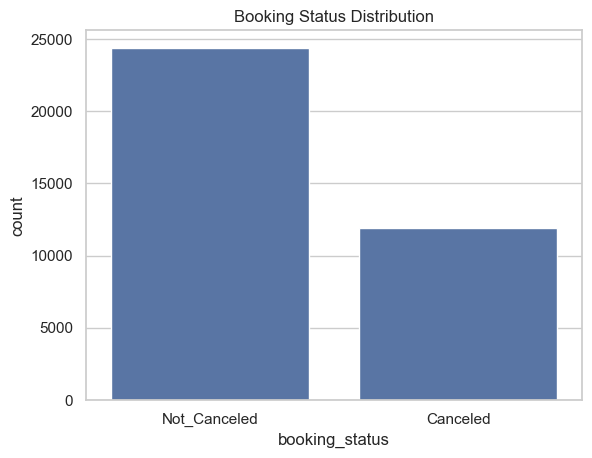

In [8]:
sns.countplot(x='booking_status', data=df)
plt.title("Booking Status Distribution")
plt.show()


In [9]:
df['total_guests'] = df['no_of_adults'] + df['no_of_children']
df['total_nights'] = df['no_of_weekend_nights'] + df['no_of_week_nights']


In [10]:
df['booking_status'] = df['booking_status'].map({
    'Not_Canceled': 0,
    'Canceled': 1
})


In [11]:
X = df.drop('booking_status', axis=1)
y = df['booking_status']


In [12]:
X = X.drop('Booking_ID', axis=1)


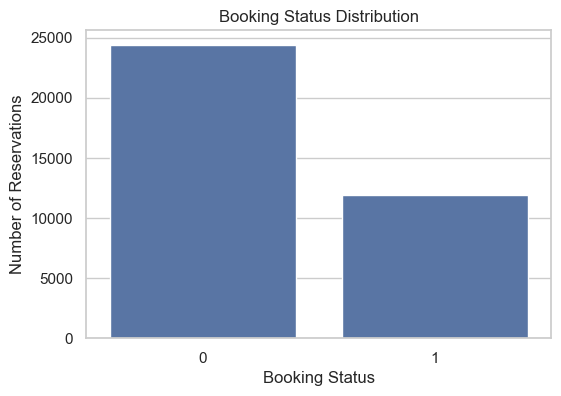

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='booking_status', data=df)
plt.title('Booking Status Distribution')
plt.xlabel('Booking Status')
plt.ylabel('Number of Reservations')
plt.show()


In [14]:
df['booking_status'].value_counts(normalize=True) * 100


booking_status
0    67.236389
1    32.763611
Name: proportion, dtype: float64

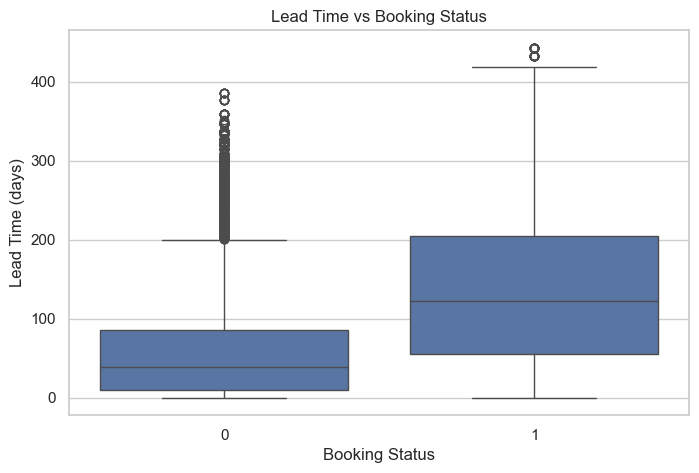

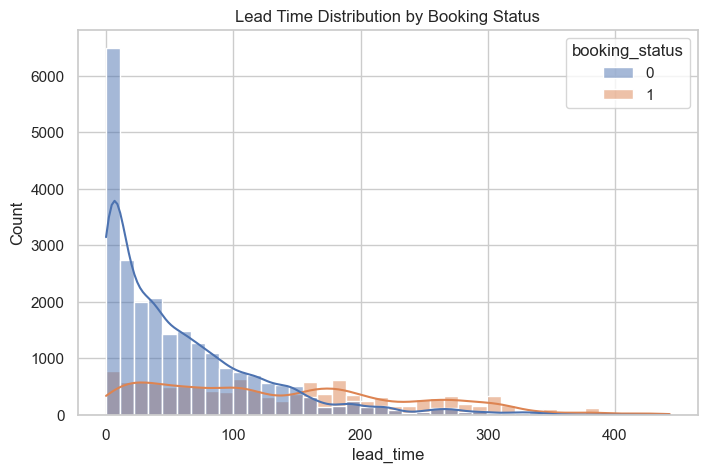

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='booking_status', y='lead_time', data=df)
plt.title('Lead Time vs Booking Status')
plt.xlabel('Booking Status')
plt.ylabel('Lead Time (days)')
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='lead_time', hue='booking_status', bins=40, kde=True)
plt.title('Lead Time Distribution by Booking Status')
plt.show()


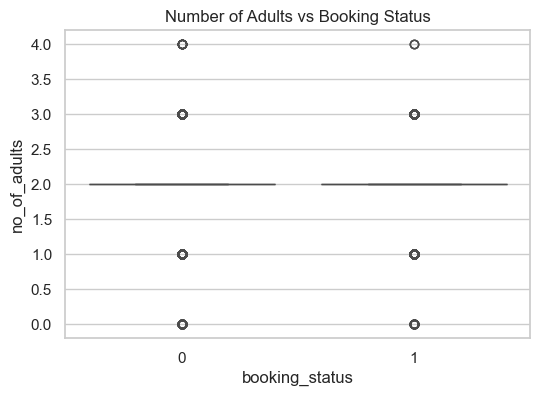

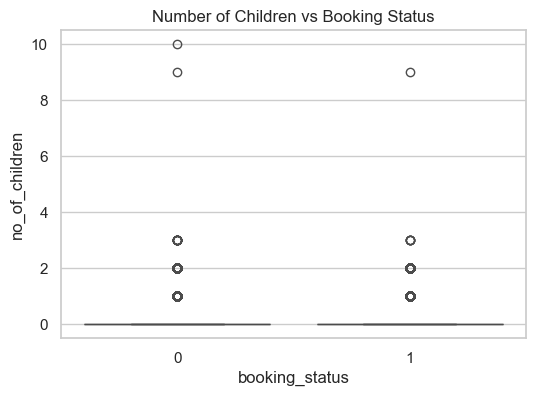

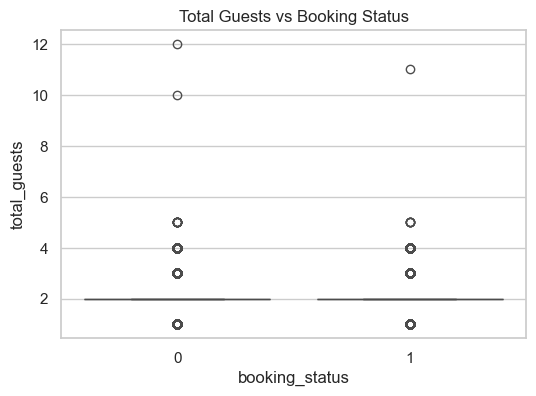

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x='booking_status', y='no_of_adults', data=df)
plt.title('Number of Adults vs Booking Status')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='booking_status', y='no_of_children', data=df)
plt.title('Number of Children vs Booking Status')
plt.show()

df['total_guests'] = df['no_of_adults'] + df['no_of_children']

plt.figure(figsize=(6,4))
sns.boxplot(x='booking_status', y='total_guests', data=df)
plt.title('Total Guests vs Booking Status')
plt.show()


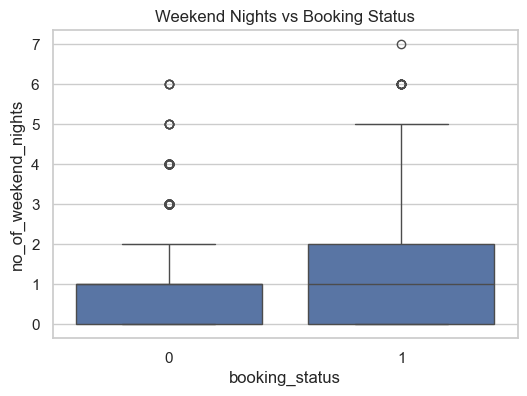

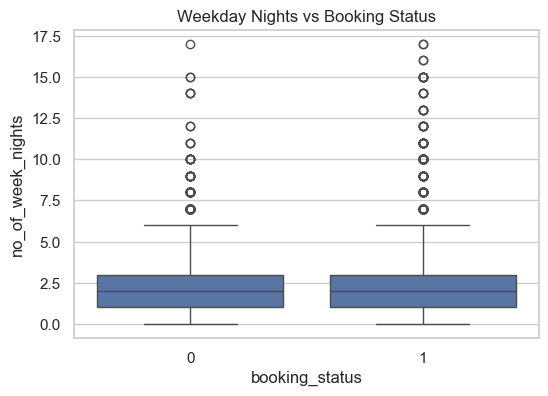

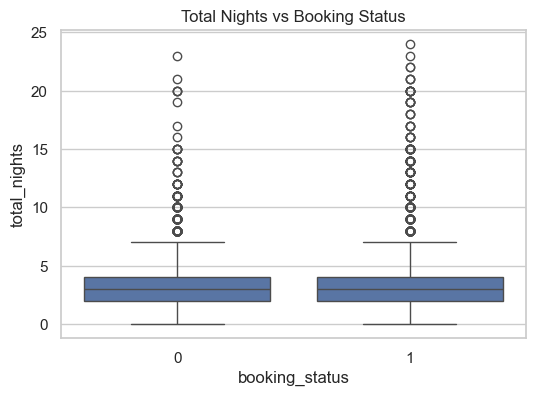

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(x='booking_status', y='no_of_weekend_nights', data=df)
plt.title('Weekend Nights vs Booking Status')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='booking_status', y='no_of_week_nights', data=df)
plt.title('Weekday Nights vs Booking Status')
plt.show()

df['total_nights'] = df['no_of_weekend_nights'] + df['no_of_week_nights']

plt.figure(figsize=(6,4))
sns.boxplot(x='booking_status', y='total_nights', data=df)
plt.title('Total Nights vs Booking Status')
plt.show()


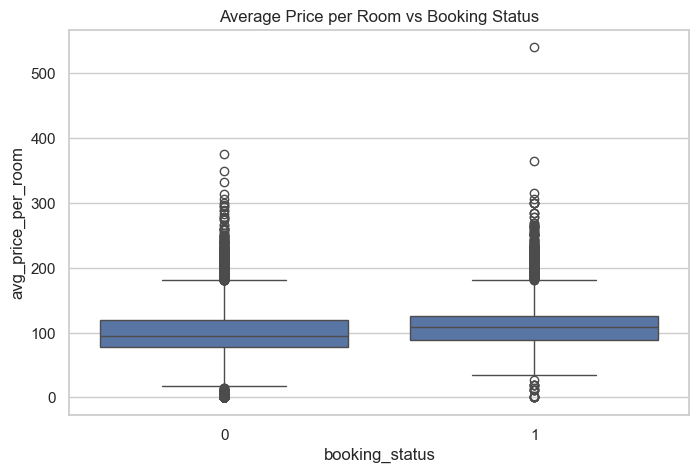

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x='booking_status', y='avg_price_per_room', data=df)
plt.title('Average Price per Room vs Booking Status')
plt.show()


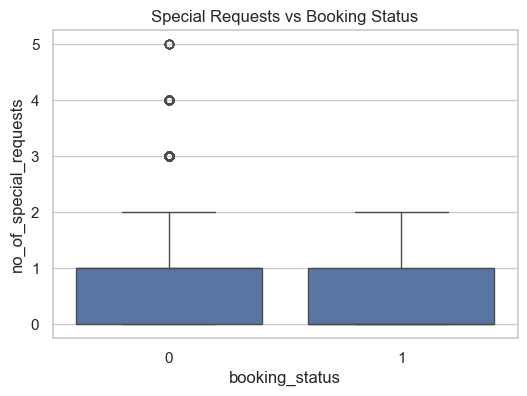

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(x='booking_status', y='no_of_special_requests', data=df)
plt.title('Special Requests vs Booking Status')
plt.show()


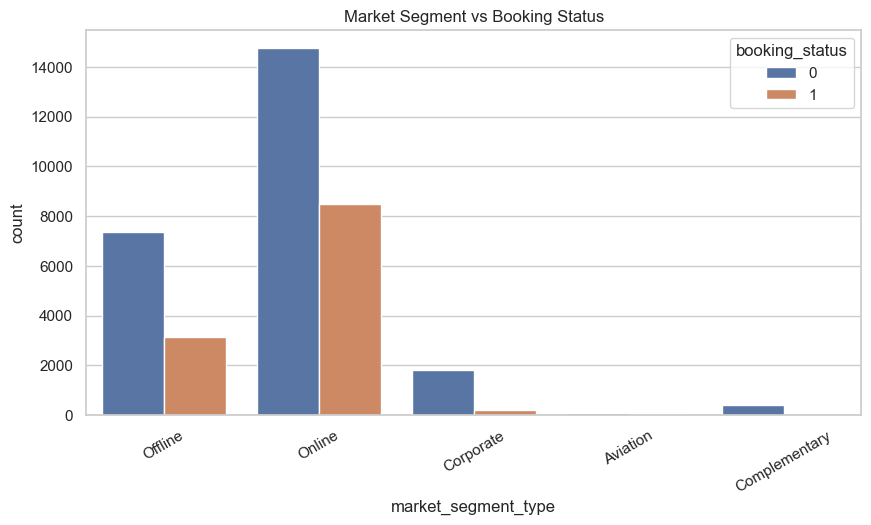

In [20]:
plt.figure(figsize=(10,5))
sns.countplot(x='market_segment_type', hue='booking_status', data=df)
plt.title('Market Segment vs Booking Status')
plt.xticks(rotation=30)
plt.show()


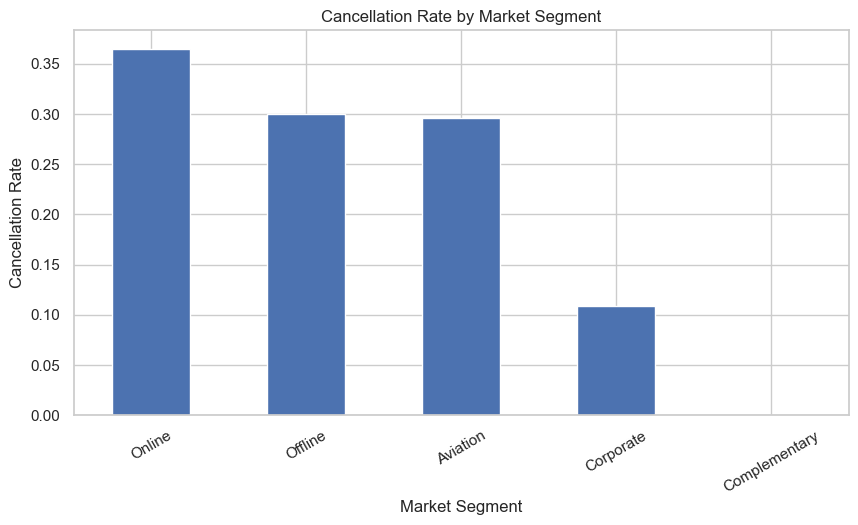

In [21]:
segment_cancel_rate = (
    df.groupby('market_segment_type')['booking_status']
    .value_counts(normalize=True)
    .unstack()
)

segment_cancel_rate[1].sort_values(ascending=False).plot(
    kind='bar', figsize=(10,5)
)

plt.title('Cancellation Rate by Market Segment')
plt.ylabel('Cancellation Rate')
plt.xlabel('Market Segment')
plt.xticks(rotation=30)
plt.show()


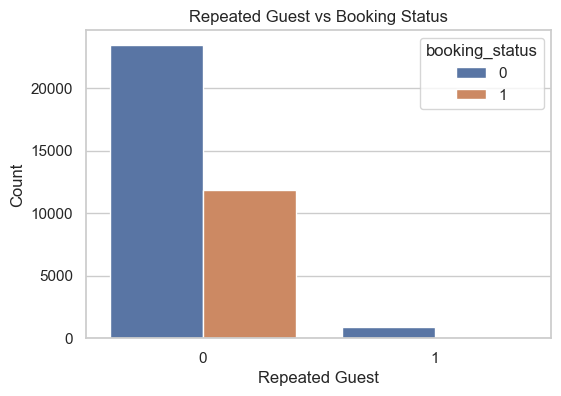

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x='repeated_guest', hue='booking_status', data=df)
plt.title('Repeated Guest vs Booking Status')
plt.xlabel('Repeated Guest')
plt.ylabel('Count')
plt.show()


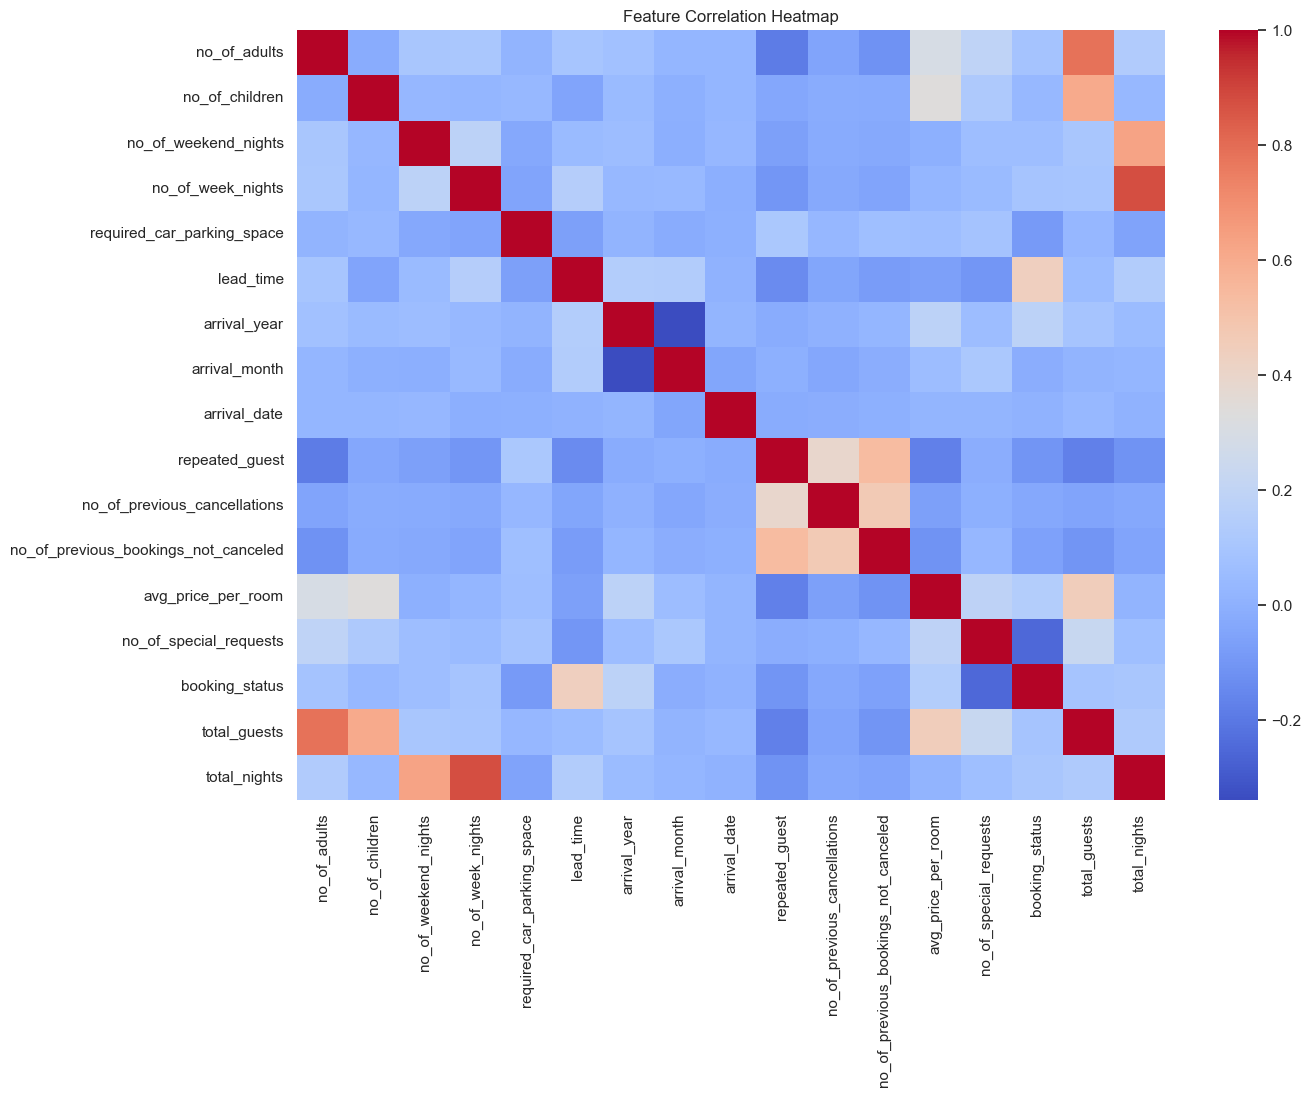

In [23]:
plt.figure(figsize=(14,10))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap='coolwarm',
    annot=False
)
plt.title('Feature Correlation Heatmap')
plt.show()


In [24]:
categorical_cols = X.select_dtypes(include='object').columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [26]:
scaler = StandardScaler()

num_cols = X_train.select_dtypes(include=np.number).columns

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


In [27]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
accuracy_score(y_test, y_pred_lr)


0.8144727773949001

In [28]:
print(classification_report(y_test, y_pred_lr))


              precision    recall  f1-score   support

           0       0.84      0.90      0.87      4878
           1       0.75      0.64      0.69      2377

    accuracy                           0.81      7255
   macro avg       0.80      0.77      0.78      7255
weighted avg       0.81      0.81      0.81      7255



In [29]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
accuracy_score(y_test, y_pred_dt)


0.8693314955203308

In [30]:
print(classification_report(y_test, y_pred_dt))


              precision    recall  f1-score   support

           0       0.90      0.90      0.90      4878
           1       0.80      0.81      0.80      2377

    accuracy                           0.87      7255
   macro avg       0.85      0.85      0.85      7255
weighted avg       0.87      0.87      0.87      7255



In [31]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
accuracy_score(y_test, y_pred_rf)


0.9040661612680909

In [32]:
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.91      0.95      0.93      4878
           1       0.89      0.81      0.85      2377

    accuracy                           0.90      7255
   macro avg       0.90      0.88      0.89      7255
weighted avg       0.90      0.90      0.90      7255



In [33]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_


In [34]:
y_pred_best = best_rf.predict(X_test)
accuracy_score(y_test, y_pred_best)


0.906960716747071

In [35]:
print(classification_report(y_test, y_pred_best))


              precision    recall  f1-score   support

           0       0.91      0.95      0.93      4878
           1       0.89      0.81      0.85      2377

    accuracy                           0.91      7255
   macro avg       0.90      0.88      0.89      7255
weighted avg       0.91      0.91      0.91      7255



In [36]:
joblib.dump(best_rf, "../outputs/models/random_forest_tuned.pkl")


['../outputs/models/random_forest_tuned.pkl']